**Import Libraries**

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["font.size"] = 11

**Load Datase**

In [129]:
df = pd.read_csv("WebTraffic_Q1_2025.csv")
df.head()

,VisitDate,SessionDuration,PageViews,ReferralSource,DeviceType,Platform,BounceRate,Conversions
0,2025-03-17,140.78,3.0,Referral,Tablet,Windows,88.24,1
1,2025-01-03,903.04,3.0,Paid Search,Tablet,Windows,48.78,0
2,2025-02-25,395.02,5.0,Social Media,Mobile,macOS,51.13,0
3,2025-01-29,273.88,6.0,Referral,Desktop,macOS,60.36,0
4,2025-03-23,50.89,5.0,Organic Search,Mobile,Linux,88.83,1


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VisitDate        600 non-null    object 
 1   SessionDuration  588 non-null    float64
 2   PageViews        591 non-null    float64
 3   ReferralSource   600 non-null    object 
 4   DeviceType       600 non-null    object 
 5   Platform         600 non-null    object 
 6   BounceRate       600 non-null    float64
 7   Conversions      600 non-null    int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 37.6+ KB


In [131]:
df.describe()

,SessionDuration,PageViews,BounceRate,Conversions
count,588.000000,591.000000,600.000000,600.000000
mean,310.725578,4.944162,55.129400,0.143333
std,310.671174,2.271846,20.421366,0.350705
min,1.520000,0.000000,20.500000,0.000000
25%,83.717500,3.000000,36.917500,0.000000
50%,218.520000,5.000000,55.350000,0.000000
75%,442.267500,6.000000,72.657500,0.000000
max,2451.730000,12.000000,89.950000,1.000000


In [132]:
df.isnull().sum()

VisitDate           0
SessionDuration    12
PageViews           9
ReferralSource      0
DeviceType          0
Platform            0
BounceRate          0
Conversions         0
dtype: int64

**Requirement 1 — Data Preparation**

In [107]:
#Convert VisitDate to datetime
df["VisitDate"] = pd.to_datetime(df["VisitDate"], errors="coerce")

In [108]:
#Create new columns for Month, Day of Week, and Week Number.
df["Month"] = df["VisitDate"].dt.month_name()
df["DayOfWeek"] = df["VisitDate"].dt.day_name()
df["WeekNumber"] = df["VisitDate"].dt.isocalendar().week

In [109]:
#Handle any missing or malformed data entries, particularly in the 'SessionDuration' and 'PageViews' columns.

df["SessionDuration"] = pd.to_numeric(df["SessionDuration"], errors="coerce")
df["PageViews"] = pd.to_numeric(df["PageViews"], errors="coerce")

df["SessionDuration"] = df["SessionDuration"].fillna(df["SessionDuration"].median())
df["PageViews"] = df["PageViews"].fillna(df["PageViews"].median())

df = df.dropna(subset=["VisitDate"])

In [110]:
df.head()

,VisitDate,SessionDuration,PageViews,ReferralSource,DeviceType,Platform,BounceRate,Conversions,Month,DayOfWeek,WeekNumber
0,2025-03-17,140.78,3.0,Referral,Tablet,Windows,88.24,1,March,Monday,12
1,2025-01-03,903.04,3.0,Paid Search,Tablet,Windows,48.78,0,January,Friday,1
2,2025-02-25,395.02,5.0,Social Media,Mobile,macOS,51.13,0,February,Tuesday,9
3,2025-01-29,273.88,6.0,Referral,Desktop,macOS,60.36,0,January,Wednesday,5
4,2025-03-23,50.89,5.0,Organic Search,Mobile,Linux,88.83,1,March,Sunday,12


In [111]:
df.isnull().sum()

VisitDate          0
SessionDuration    0
PageViews          0
ReferralSource     0
DeviceType         0
Platform           0
BounceRate         0
Conversions        0
Month              0
DayOfWeek          0
WeekNumber         0
dtype: int64

**Requirement 2 — Traffic Trend Analysis**

**Daily Number of Sessions**

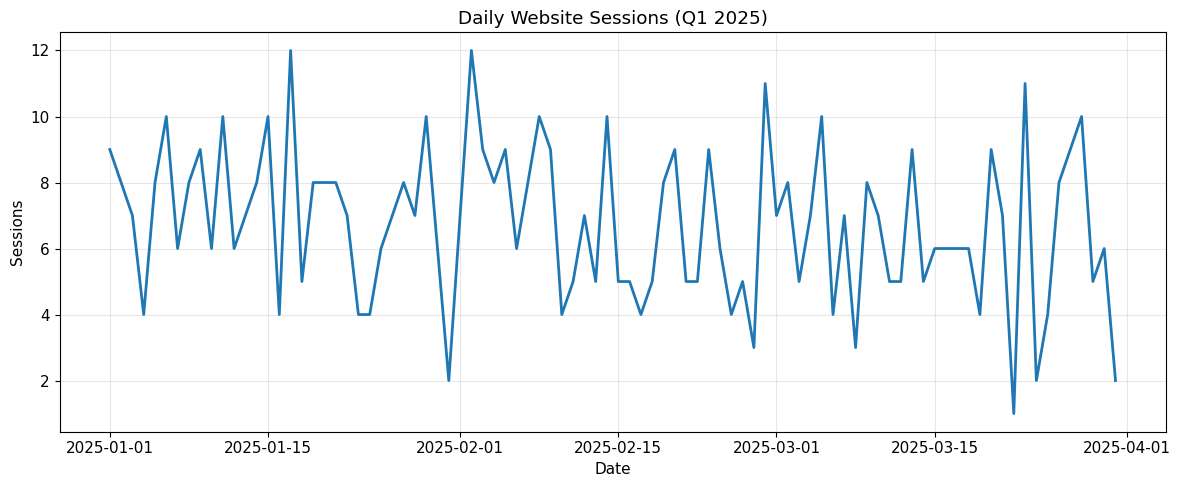

In [112]:
#Plot the daily number of sessions over time for Q1.

daily_sessions = df.groupby("VisitDate").size()

plt.figure(figsize=(12,5))
plt.plot(daily_sessions.index,daily_sessions.values,linewidth=2)
plt.title("Daily Website Sessions (Q1 2025)")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Weekly Traffic Comparison**

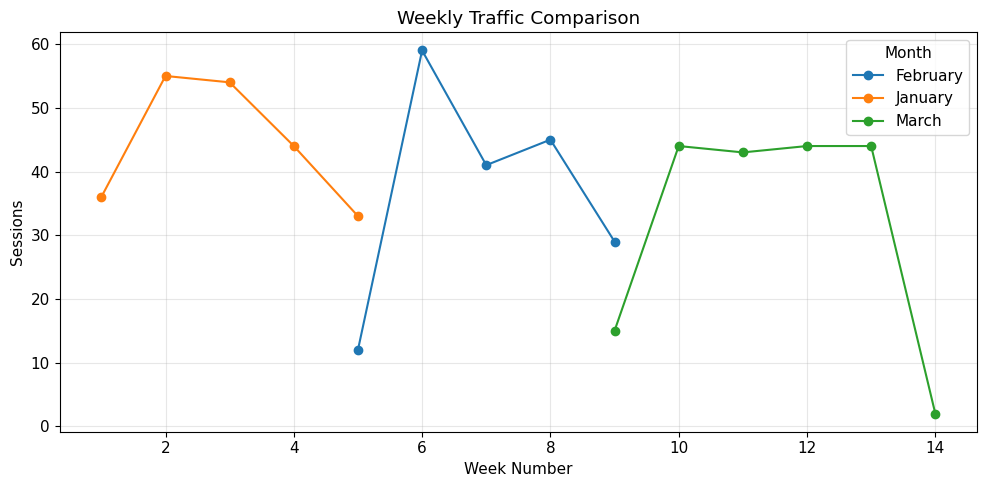

In [113]:
weekly = df.groupby(["Month","WeekNumber"]).size().unstack(0)

weekly.plot(marker="o")

plt.title("Weekly Traffic Comparison")
plt.xlabel("Week Number")
plt.ylabel("Sessions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Requirement 3 — User Engagement Metrics**

In [114]:
#Calculate the average session duration and average page views per session.
avg_duration = df["SessionDuration"].mean()
avg_pageviews = df["PageViews"].mean()

print("Average Session Duration:", round(avg_duration,2))
print("Average Page Views:", round(avg_pageviews,2))

Average Session Duration: 308.88
Average Page Views: 4.94


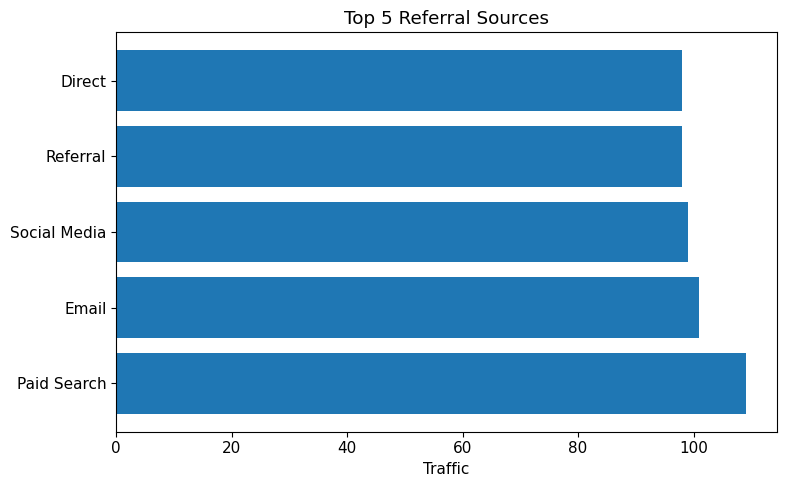

In [115]:
# Identify the top 5 referral sources bringing the most traffic and visualize this with a horizontal bar chart. 
top_sources = df["ReferralSource"].value_counts().head(5)

plt.figure(figsize=(8,5))
plt.barh(top_sources.index,top_sources.values)
plt.title("Top 5 Referral Sources")
plt.xlabel("Traffic")
plt.tight_layout()
plt.show()

**Requirement 4 — Conversion Analysis**

In [116]:
print(df.columns.tolist())

['VisitDate', 'SessionDuration', 'PageViews', 'ReferralSource', 'DeviceType', 'Platform', 'BounceRate', 'Conversions', 'Month', 'DayOfWeek', 'WeekNumber']


In [117]:
print(df.head())

   VisitDate  SessionDuration  PageViews  ReferralSource DeviceType Platform  \
0 2025-03-17           140.78        3.0        Referral     Tablet  Windows   
1 2025-01-03           903.04        3.0     Paid Search     Tablet  Windows   
2 2025-02-25           395.02        5.0    Social Media     Mobile    macOS   
3 2025-01-29           273.88        6.0        Referral    Desktop    macOS   
4 2025-03-23            50.89        5.0  Organic Search     Mobile    Linux   

   BounceRate  Conversions     Month  DayOfWeek  WeekNumber  
0       88.24            1     March     Monday          12  
1       48.78            0   January     Friday           1  
2       51.13            0  February    Tuesday           9  
3       60.36            0   January  Wednesday           5  
4       88.83            1     March     Sunday          12  


In [118]:
# Total sessions
total_sessions = len(df)

# Total conversions
total_conversions = df["Conversions"].sum()

# Overall conversion rate
conversion_rate = (total_conversions / total_sessions) * 100

print("Total Sessions:", total_sessions)
print("Total Conversions:", total_conversions)
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Total Sessions: 600
Total Conversions: 86
Overall Conversion Rate: 14.33%


In [119]:
print(df["Conversions"].value_counts(dropna=False))

Conversions
0    514
1     86
Name: count, dtype: int64


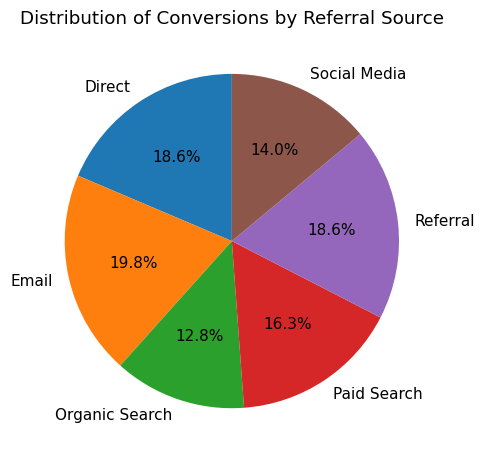

In [120]:
plt.figure(figsize=(5, 5))

plt.pie(
    conversion_sources.values,
    labels=conversion_sources.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Conversions by Referral Source")

plt.tight_layout()
plt.show()

**Requirement 5 — Device & Platform Insights**

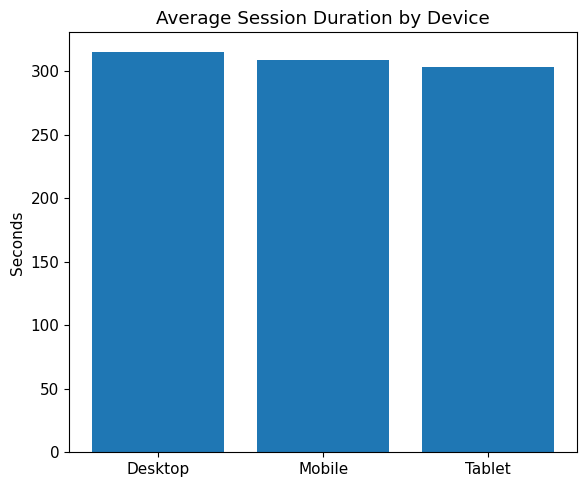

In [121]:
#Group data by device type (Desktop, Mobile, Tablet) and show average session duration for each. 

device_duration = df.groupby("DeviceType")["SessionDuration"].mean()

plt.figure(figsize=(6,5))
plt.bar(device_duration.index,device_duration.values)

plt.title("Average Session Duration by Device")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()

In [122]:
#Conversion Rate by Device Type

device_summary = df.groupby("DeviceType").agg(Sessions=("DeviceType", "size"),Conversions=("Conversions", "sum"))

device_summary["ConversionRate"] = (device_summary["Conversions"] / device_summary["Sessions"]) * 100

print("Device Conversion Analysis:")
print(device_summary)

Device Conversion Analysis:
            Sessions  Conversions  ConversionRate
DeviceType                                       
Desktop          195           30       15.384615
Mobile           206           25       12.135922
Tablet           199           31       15.577889


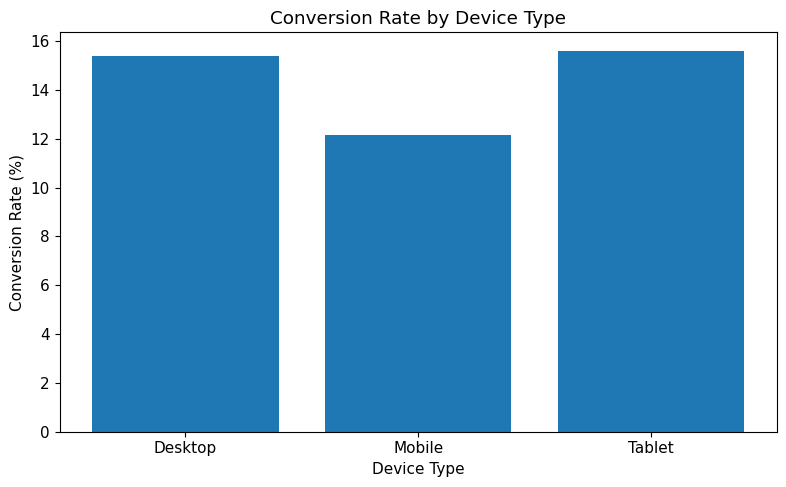

In [123]:
plt.figure(figsize=(8, 5))

plt.bar(device_summary.index,device_summary["ConversionRate"])

plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

**Requirement 6 — Bounce Rate Pattern**

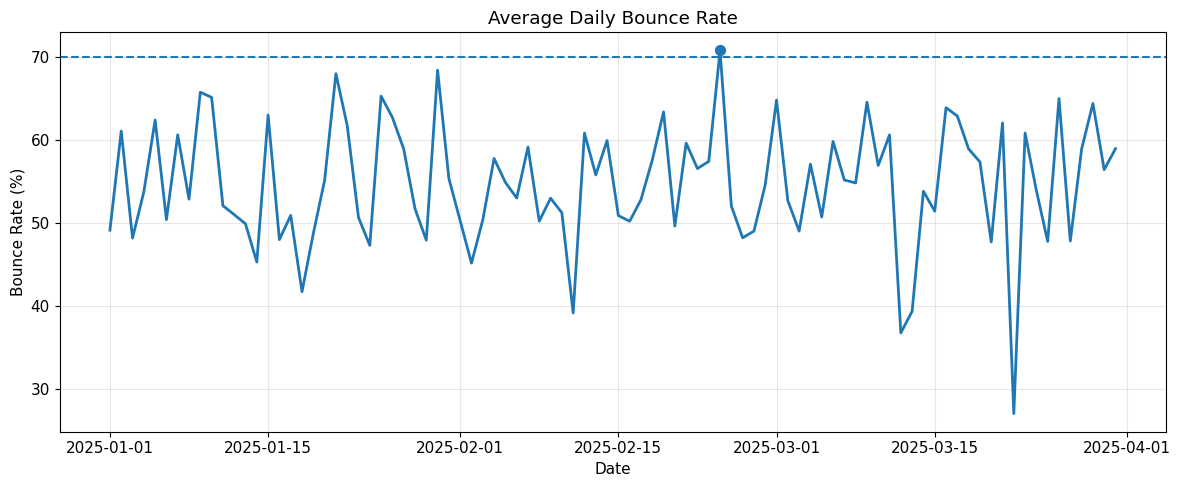

In [124]:
daily_bounce = df.groupby("VisitDate")["BounceRate"].mean()

plt.figure(figsize=(12,5))
plt.plot(daily_bounce.index,daily_bounce.values,linewidth=2)

high = daily_bounce[daily_bounce>70]

plt.scatter(high.index,high.values,s=50)

plt.axhline(70,linestyle="--")

plt.title("Average Daily Bounce Rate")
plt.xlabel("Date")
plt.ylabel("Bounce Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

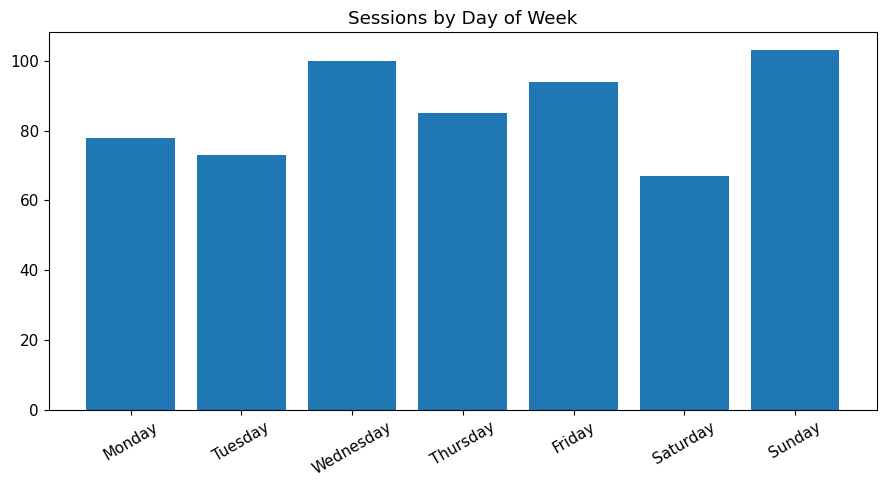

In [125]:
days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dow = df["DayOfWeek"].value_counts().reindex(days)

plt.figure(figsize=(9,5))
plt.bar(dow.index,dow.values)

plt.title("Sessions by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Executive Dashboard Summary**

In [133]:
print("="*40)
print("Website Traffic")
print("="*40)

print(f"Total Sessions      : {len(df)}")
print(f"Conversions         : {df["Conversions"].sum()}")
print(f"Conversion Rate     : {conversion_rate:.2f}%")
print(f"Avg Session Duration: {avg_duration:.2f}")
print(f"Avg Page Views      : {avg_pageviews:.2f}")

Website Traffic
Total Sessions      : 600
Conversions         : 86
Conversion Rate     : 14.33%
Avg Session Duration: 308.88
Avg Page Views      : 4.95
